In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set styling for prettier plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [15]:
import os

# List all files in the current directory
files = os.listdir('.')
print("Files in current directory:")
for f in files:
    print(f"  - {f}")

Files in current directory:
  - Online_Retail.csv
  - customer_analysis.ipynb
  - Online Retail.xlsx


In [16]:
import pandas as pd
import numpy as np

print("=" * 50)
print("LOADING E-COMMERCE DATASET")
print("=" * 50)

print("\nLoading data from file...")
# Use latin-1 encoding (works with special characters like £)
df = pd.read_csv('Online_Retail.csv', encoding='latin-1')

print(f"\n✓ Dataset loaded: {len(df):,} rows, {len(df.columns)} columns")
print(f"✓ Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"✓ Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

LOADING E-COMMERCE DATASET

Loading data from file...

✓ Dataset loaded: 541,909 rows, 8 columns
✓ Date range: 1/10/11 10:04 to 9/9/11 9:52
✓ Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

    InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/10 8:26       2.55     17850.0  United Kingdom  
1  12/1/10 8:26       3.39     17850.0  United Kingdom  
2  12/1/10 8:26       2.75     17850.0  United Kingdom  
3  12/1/10 8:26       3.39     17850.0  United Kingdom  
4  12/1

In [18]:
print("Column names in the dataset:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Column names in the dataset:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [19]:
print("=" * 50)
print("DATA CLEANING")
print("=" * 50)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove rows with missing values in key columns
print(f"\nBefore cleaning: {len(df):,} rows")
df = df.dropna(subset=['CustomerID', 'UnitPrice', 'Quantity'])
print(f"After removing missing values: {len(df):,} rows")

# Remove negative quantities (returns/cancellations)
df = df[df['Quantity'] > 0]
print(f"After removing negative quantities: {len(df):,} rows")

# Remove zero or negative prices
df = df[df['UnitPrice'] > 0]
print(f"After removing invalid prices: {len(df):,} rows")

# Create new column: Total Purchase Amount
df['Total_Purchase'] = df['Quantity'] * df['UnitPrice']

# Create Year-Month column for trends
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print("\n✓ Data cleaned successfully!")
print(f"\nKey numbers:")
print(f"  - Total transactions: {len(df):,}")
print(f"  - Unique customers: {df['CustomerID'].nunique():,}")
print(f"  - Countries: {df['Country'].nunique()}")
print(f"  - Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"  - Total revenue: ${df['Total_Purchase'].sum():,.2f}")

DATA CLEANING

Before cleaning: 541,909 rows
After removing missing values: 406,829 rows
After removing negative quantities: 397,924 rows
After removing invalid prices: 397,884 rows

✓ Data cleaned successfully!

Key numbers:
  - Total transactions: 397,884
  - Unique customers: 4,338
  - Countries: 37
  - Date range: 2010-12-01 to 2011-12-09
  - Total revenue: $8,911,407.90


In [20]:
print("=" * 50)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# Basic statistics
print("\nPurchase Amount Statistics:")
print(f"  - Average purchase: ${df['Total_Purchase'].mean():.2f}")
print(f"  - Median purchase: ${df['Total_Purchase'].median():.2f}")
print(f"  - Min purchase: ${df['Total_Purchase'].min():.2f}")
print(f"  - Max purchase: ${df['Total_Purchase'].max():.2f}")

print("\nCustomer Statistics:")
customer_stats = df.groupby('CustomerID').agg({
    'Total_Purchase': 'sum',
    'InvoiceNo': 'count'
}).rename(columns={'InvoiceNo': 'Num_Purchases'})

print(f"  - Average customer lifetime value: ${customer_stats['Total_Purchase'].mean():.2f}")
print(f"  - Top customer spent: ${customer_stats['Total_Purchase'].max():.2f}")
print(f"  - Average purchases per customer: {customer_stats['Num_Purchases'].mean():.1f}")

print("\nTop 10 Countries by Revenue:")
top_countries = df.groupby('Country')['Total_Purchase'].sum().nlargest(10)
for country, revenue in top_countries.items():
    print(f"  {country}: ${revenue:,.2f}")

print("\n✓ Analysis complete!")

EXPLORATORY DATA ANALYSIS

Purchase Amount Statistics:
  - Average purchase: $22.40
  - Median purchase: $11.80
  - Min purchase: $0.00
  - Max purchase: $168469.60

Customer Statistics:
  - Average customer lifetime value: $2054.27
  - Top customer spent: $280206.02
  - Average purchases per customer: 91.7

Top 10 Countries by Revenue:
  United Kingdom: $7,308,391.55
  Netherlands: $285,446.34
  EIRE: $265,545.90
  Germany: $228,867.14
  France: $209,024.05
  Australia: $138,521.31
  Spain: $61,577.11
  Switzerland: $56,443.95
  Belgium: $41,196.34
  Sweden: $38,378.33

✓ Analysis complete!


CREATING VISUALIZATIONS

1. Creating purchase amount distribution chart...
2. Creating top countries chart...
3. Creating monthly revenue trend chart...
4. Creating customer value distribution chart...

✓ Visualizations saved as 'customer_analytics.png'


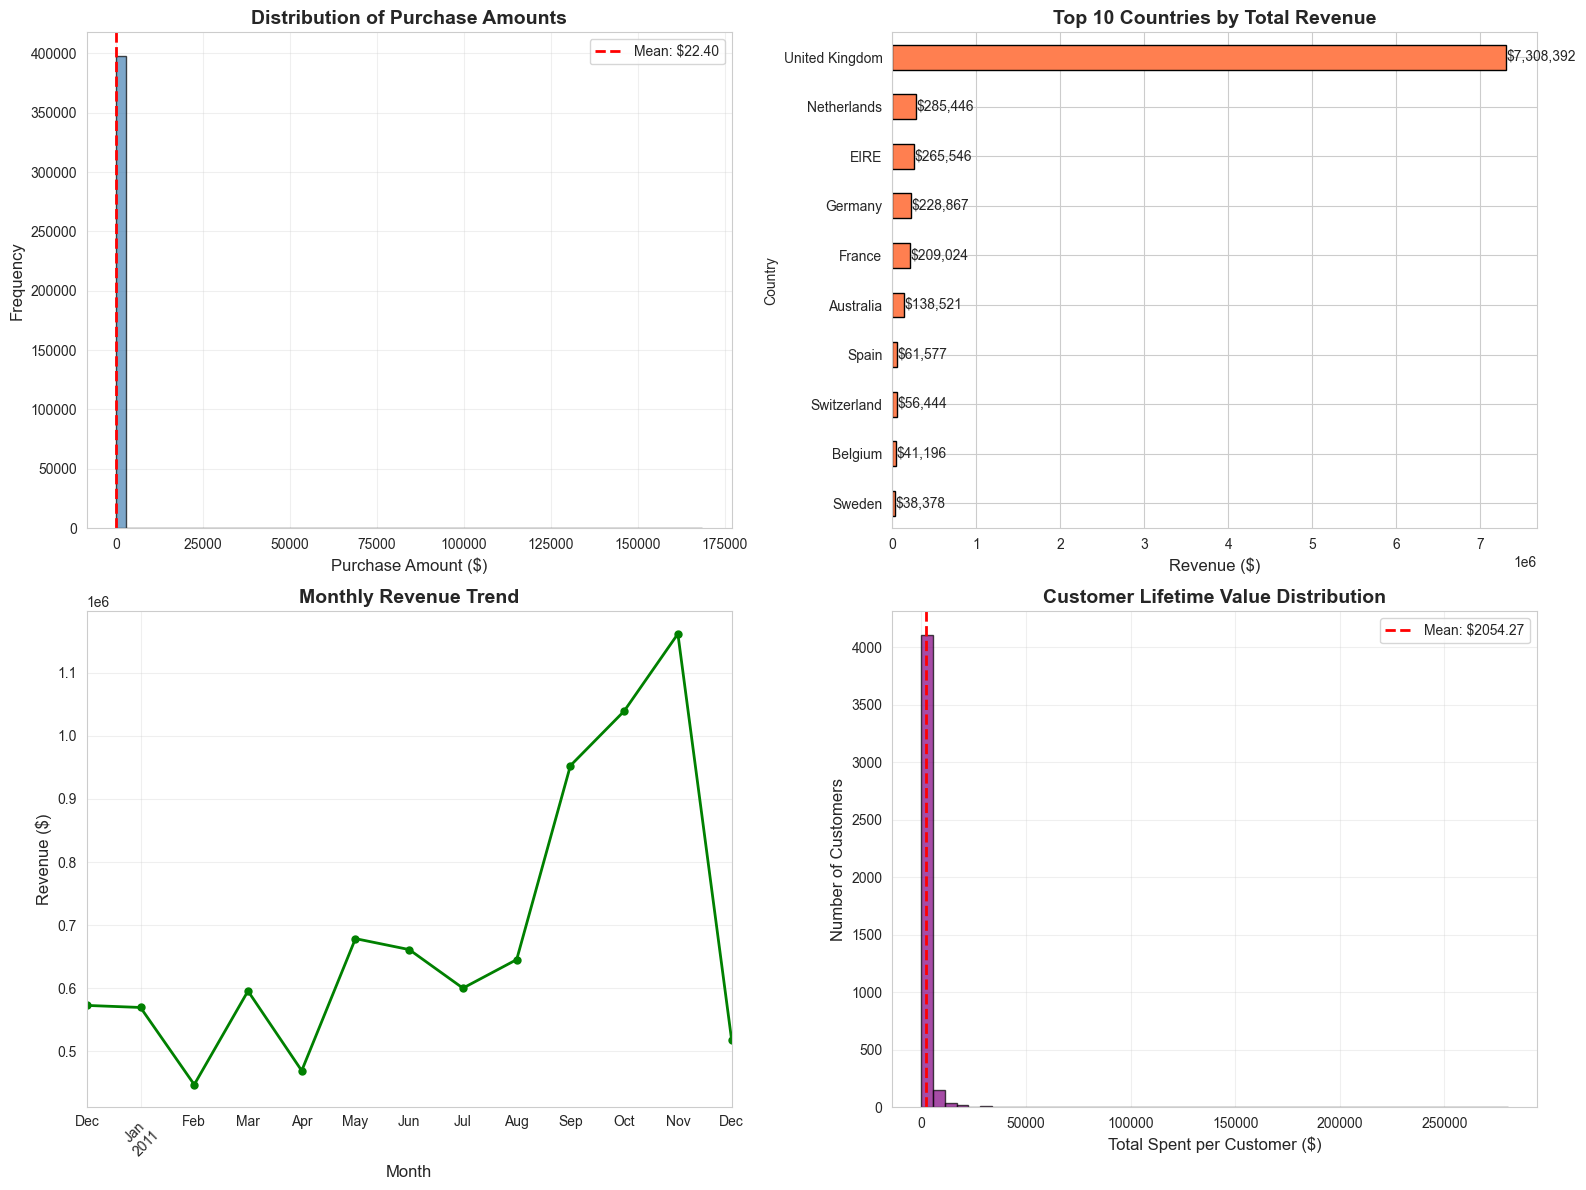


✓ All visualizations complete!


In [21]:
print("=" * 50)
print("CREATING VISUALIZATIONS")
print("=" * 50)

# Create a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ===== CHART 1: Purchase Amount Distribution =====
print("\n1. Creating purchase amount distribution chart...")
axes[0, 0].hist(df['Total_Purchase'], bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Purchase Amounts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Purchase Amount ($)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].axvline(df['Total_Purchase'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: ${df['Total_Purchase'].mean():.2f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ===== CHART 2: Top 10 Countries by Revenue =====
print("2. Creating top countries chart...")
top_10_countries = df.groupby('Country')['Total_Purchase'].sum().nlargest(10)
top_10_countries.plot(kind='barh', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Revenue ($)', fontsize=12)
axes[0, 1].invert_yaxis()
for i, v in enumerate(top_10_countries):
    axes[0, 1].text(v + 5000, i, f'${v:,.0f}', va='center', fontsize=10)

# ===== CHART 3: Monthly Revenue Trend =====
print("3. Creating monthly revenue trend chart...")
monthly_revenue = df.groupby('YearMonth')['Total_Purchase'].sum()
monthly_revenue.index = monthly_revenue.index.to_timestamp()
monthly_revenue.plot(ax=axes[1, 0], color='green', linewidth=2, marker='o', markersize=5)
axes[1, 0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Month', fontsize=12)
axes[1, 0].set_ylabel('Revenue ($)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# ===== CHART 4: Customer Lifetime Value Distribution =====
print("4. Creating customer value distribution chart...")
customer_ltv = df.groupby('CustomerID')['Total_Purchase'].sum()
axes[1, 1].hist(customer_ltv, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Customer Lifetime Value Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Total Spent per Customer ($)', fontsize=12)
axes[1, 1].set_ylabel('Number of Customers', fontsize=12)
axes[1, 1].axvline(customer_ltv.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: ${customer_ltv.mean():.2f}")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plt.savefig('customer_analytics.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualizations saved as 'customer_analytics.png'")
plt.show()

print("\n✓ All visualizations complete!")

In [23]:
print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

# Calculate key metrics
total_revenue = df['Total_Purchase'].sum()
avg_order_value = df['Total_Purchase'].mean()
num_customers = df['CustomerID'].nunique()
num_transactions = len(df)
top_country = df.groupby('Country')['Total_Purchase'].sum().idxmax()
top_country_revenue = df.groupby('Country')['Total_Purchase'].sum().max()

# Customer segmentation
customer_ltv = df.groupby('CustomerID')['Total_Purchase'].sum()
top_10_percent = customer_ltv.nlargest(int(num_customers * 0.1))
top_10_revenue = top_10_percent.sum()

print(f"\n📊 REVENUE INSIGHTS:")
print(f"   • Total Revenue: ${total_revenue:,.2f}")
print(f"   • Average Order Value: ${avg_order_value:.2f}")
print(f"   • Top Country: {top_country} (${top_country_revenue:,.2f})")

print(f"\n👥 CUSTOMER INSIGHTS:")
print(f"   • Total Customers: {num_customers:,}")
print(f"   • Total Transactions: {num_transactions:,}")
print(f"   • Avg Transactions per Customer: {num_transactions/num_customers:.1f}")

print(f"\n💰 CUSTOMER VALUE INSIGHTS:")
print(f"   • Top 10% of customers generate: ${top_10_revenue:,.2f} ({top_10_revenue/total_revenue*100:.1f}% of revenue)")
print(f"   • Average customer lifetime value: ${customer_ltv.mean():.2f}")
print(f"   • Median customer lifetime value: ${customer_ltv.median():.2f}")

print(f"\n🌍 GEOGRAPHIC INSIGHTS:")
top_5 = df.groupby('Country')['Total_Purchase'].sum().nlargest(5)
total_top_5 = top_5.sum()
print(f"   • Top 5 countries generate: ${total_top_5:,.2f} ({total_top_5/total_revenue*100:.1f}% of revenue)")
for i, (country, revenue) in enumerate(top_5.items(), 1):
    print(f"     {i}. {country}: ${revenue:,.2f}")

print("\n✓ Analysis complete!")

KEY BUSINESS INSIGHTS

📊 REVENUE INSIGHTS:
   • Total Revenue: $8,911,407.90
   • Average Order Value: $22.40
   • Top Country: United Kingdom ($7,308,391.55)

👥 CUSTOMER INSIGHTS:
   • Total Customers: 4,338
   • Total Transactions: 397,884
   • Avg Transactions per Customer: 91.7

💰 CUSTOMER VALUE INSIGHTS:
   • Top 10% of customers generate: $5,465,733.36 (61.3% of revenue)
   • Average customer lifetime value: $2054.27
   • Median customer lifetime value: $674.49

🌍 GEOGRAPHIC INSIGHTS:
   • Top 5 countries generate: $8,297,274.98 (93.1% of revenue)
     1. United Kingdom: $7,308,391.55
     2. Netherlands: $285,446.34
     3. EIRE: $265,545.90
     4. Germany: $228,867.14
     5. France: $209,024.05

✓ Analysis complete!
